# Hill's Pet Nutrition – Media Mix Model & Saturation Curve Analysis

In [ ]:
"""
S3 (MMM / ROAS) + S4 (Saturation Curves / Diminishing Returns)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 0. BRAND COLOURS

HILLS_RED   = "#C8102E"
HILLS_BLUE  = "#003087"
HILLS_GREY  = "#6D6E71"
TV_COLOR    = "#003087"
PROG_COLOR  = "#C8102E"
DARK_BG     = "#0D1117"
CARD_BG     = "#161B22"
TEXT_COLOR  = "#E6EDF3"
MUTED       = "#8B949E"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor":   CARD_BG,
    "axes.edgecolor":   "#30363D",
    "axes.labelcolor":  TEXT_COLOR,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "text.color":       TEXT_COLOR,
    "grid.color":       "#21262D",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   10,
})


#  1. LOAD DATA

In [ ]:
# 1. LOAD DATA

mix    = pd.read_csv("mix_marketing_analysis.csv")
attrib = pd.read_csv("attrib_final_scopes.csv")
cap    = pd.read_csv("optimal_capping_agg.csv")



In [ ]:
mix.head()


,path,reach,impressions,total_cost,users_that_purchased,sales,purchases
0,"['Contextual', 'Retargeting', 'tv_campaign']",25344,303468,32276.423211,547,85528.09,1925.0
1,"['Contextual', 'Retargeting']",154945,1216454,79165.767312,9392,1432343.36,33976.0
2,"['Contextual', 'tv_campaign']",55809,360715,42131.958986,732,88181.57,2148.0
3,['Contextual'],3060101,10323729,376333.922320,22278,2243600.65,53904.0
4,"['Retargeting', 'tv_campaign']",216550,1268145,209267.579852,5724,1018464.71,23545.0


In [ ]:
attrib.head()


,reach,total_cost,nb_purchasers,nb_orders,nb_articles,sales,first_order_date,last_order_date,scope
0,6350654,1.936033e+06,306759.0,1372811.0,162656.0,6540287.88,2024-01-01 00:15:02,2024-06-30 23:59:57,All_Campaigns
1,1730479,3.563472e+05,210349.0,1064638.0,134174.0,5409254.65,2024-01-01 00:15:02,2024-06-30 23:59:57,Retargeting_Only
2,3305798,4.312593e+05,91489.0,280550.0,18706.0,734937.86,2024-01-01 05:07:18,2024-06-30 23:59:08,Contextual_Only
3,1804519,1.148427e+06,19642.0,71625.0,13399.0,542407.06,2024-03-01 00:47:51,2024-06-30 23:55:59,TV_Only
4,4850778,7.876065e+05,290870.0,1306895.0,150035.0,6030660.08,2024-01-01 00:15:02,2024-06-30 23:59:57,Publisher_Only


In [ ]:
cap.head()

,Unnamed: 0,nb_imp_bracket,imp_cost,sales,dsp_id,imp_cost_brackets,nb_users_brackets,sales_brackets
0,0,1,"485159,94521030004","2701404,74",3693977,"485159,94521030004",3693977,"2701404,74"
1,1,2,"220758,41232130004","1001390,61",1008217,"705918,3575316",4702194,"3702795,35"
2,2,3,"147852,4522338","520591,96",505091,"853770,8097654",5207285,"4223387,3100000005"
3,3,4-5,"217186,55098390003","625689,26",529454,"1070957,3607493",5736739,"4849076,57"
4,4,6-10,"323564,8086619","822511,9199999999",486283,"1394522,1694112",6223022,"5671588,49"


# 2. CLEAN & PARSE

In [ ]:
# 2a. fix decimal comma in capping file
for col in ["imp_cost", "sales", "imp_cost_brackets",
            "nb_users_brackets", "sales_brackets"]:
    cap[col] = cap[col].astype(str).str.replace(",", ".").astype(float)

In [ ]:
# 2b. channel presence flags from path column
mix["has_tv"]      = mix["path"].str.contains("tv_campaign")
mix["has_retarg"]  = mix["path"].str.contains("Retargeting")
mix["has_context"] = mix["path"].str.contains("Contextual")


In [ ]:
# 2c. attrib: index by scope
# Check if 'scope' is already the index. If so, reset it to make it a column again.
if attrib.index.name == "scope":
    attrib = attrib.reset_index()

# Now, set 'scope' as the index, ensuring it's available as a column.
attrib = attrib.set_index("scope")

#  *3. Step3 – MEDIA MIX MODEL (MMM) + ROAS*

In [ ]:
# --- 3a. Channel-level spend, sales, purchasers from attrib scopes ---
channels = {
    "TV":         {"scope": "TV_Only",         "color": TV_COLOR},
    "Programmatic": {"scope": "Publisher_Only", "color": PROG_COLOR},
    "Retargeting":  {"scope": "Retargeting_Only","color": "#F0A500"},
    "Contextual":   {"scope": "Contextual_Only", "color": "#22C55E"},
}

ch_data = {}
for ch, meta in channels.items():
    row = attrib.loc[meta["scope"]]
    ch_data[ch] = {
        "spend":      row["total_cost"],
        "sales":      row["sales"],
        "purchasers": row["nb_purchasers"],
        "orders":     row["nb_orders"],
        "color":      meta["color"],
    }

ch_df = pd.DataFrame(ch_data).T
ch_df["ROAS"]     = ch_df["sales"] / ch_df["spend"]
ch_df["CPO"]      = ch_df["spend"] / ch_df["orders"]          # Cost per Order
ch_df["conv_rate"]= (ch_df["purchasers"] / attrib.loc["All_Campaigns","reach"]) * 100

print("\n===== CHANNEL PERFORMANCE TABLE =====")
print(ch_df[["spend","sales","ROAS","CPO","conv_rate"]].round(2).to_string())


===== CHANNEL PERFORMANCE TABLE =====
                       spend       sales       ROAS        CPO conv_rate
TV            1148426.987886   542407.06   0.472304  16.033885  0.309291
Programmatic   787606.489322  6030660.08   7.656946   0.602655  4.580158
Retargeting    356347.169315  5409254.65  15.179732   0.334712  3.312242
Contextual     431259.320007   734937.86   1.704167   1.537192  1.440623


In [ ]:
# --- 3b. Adstock / Carryover simulation ---
# We simulate weekly spend using attrib date range (≈ 26 weeks for TV, full 26 for digital)
np.random.seed(42)
n_weeks = 26
tv_weekly     = np.random.exponential(ch_data["TV"]["spend"] / n_weeks, n_weeks)
prog_weekly   = np.random.exponential(ch_data["Programmatic"]["spend"] / n_weeks, n_weeks)

def adstock(spend_arr, decay=0.5):
    """Simple geometric adstock / carryover."""
    result = np.zeros_like(spend_arr)
    for i, s in enumerate(spend_arr):
        if i == 0:
            result[i] = s
        else:
            result[i] = s + decay * result[i-1]
    return result

tv_adstock   = adstock(tv_weekly,   decay=0.55)   # TV has longer carry-over
prog_adstock = adstock(prog_weekly, decay=0.20)   # Digital decays faster

In [ ]:
# --- 3c. Baseline vs Incremental decomposition ---
all_sales  = attrib.loc["All_Campaigns","sales"]
base_pct   = 0.45     # assume 45 % baseline (non-media organic)
base_sales = all_sales * base_pct
incr_sales = all_sales - base_sales

tv_share   = ch_data["TV"]["sales"]   / (ch_data["TV"]["sales"] + ch_data["Programmatic"]["sales"] +
             ch_data["Retargeting"]["sales"] + ch_data["Contextual"]["sales"])
prog_share = ch_data["Programmatic"]["sales"] / (ch_data["TV"]["sales"] + ch_data["Programmatic"]["sales"] +
             ch_data["Retargeting"]["sales"] + ch_data["Contextual"]["sales"])
retarg_share  = ch_data["Retargeting"]["sales"] / (ch_data["TV"]["sales"] + ch_data["Programmatic"]["sales"] +
                ch_data["Retargeting"]["sales"] + ch_data["Contextual"]["sales"])
context_share = ch_data["Contextual"]["sales"] / (ch_data["TV"]["sales"] + ch_data["Programmatic"]["sales"] +
                ch_data["Retargeting"]["sales"] + ch_data["Contextual"]["sales"])

decomp = {
    "Baseline (Organic)": base_sales,
    "TV":                 incr_sales * tv_share,
    "Programmatic":       incr_sales * prog_share,
    "Retargeting":        incr_sales * retarg_share,
    "Contextual":         incr_sales * context_share,
}
decomp_colors = [HILLS_GREY, TV_COLOR, PROG_COLOR, "#F0A500", "#22C55E"]

# 4. Step4 – SATURATION CURVES & DIMINISHING RETURNS

In [ ]:
# 4a. Use capping data as the programmatic saturation signal
#     nb_imp_bracket = frequency bucket; imp_cost = marginal spend; sales = marginal sales
cap["marginal_ROAS"] = cap["sales"] / cap["imp_cost"]

# Label bracket midpoints for x-axis
bracket_labels = cap["nb_imp_bracket"].tolist()
bracket_x      = np.arange(len(bracket_labels))

# Cumulative spend & sales (already provided as brackets columns)
cum_spend = cap["imp_cost_brackets"].values
cum_sales = cap["sales_brackets"].values
cum_ROAS  = cum_sales / cum_spend

In [ ]:
# 4b. TV saturation – Hill function (simulated with realistic params)
#     S(x) = x^alpha / (K^alpha + x^alpha)
tv_spend_range = np.linspace(0, ch_data["TV"]["spend"] * 2, 400)
alpha_tv = 0.7
K_tv     = ch_data["TV"]["spend"] * 0.6      # saturation inflection
tv_response = (tv_spend_range**alpha_tv) / (K_tv**alpha_tv + tv_spend_range**alpha_tv)
tv_response_sales = tv_response * ch_data["TV"]["sales"] * 1.8   # scale to sales units

In [ ]:
# 4c. Programmatic saturation – using cumulative real data + extrapolation
prog_spend_range = np.linspace(0, ch_data["Programmatic"]["spend"] * 2.5, 400)
alpha_prog = 0.85                              # flatter → less diminishing returns
K_prog     = ch_data["Programmatic"]["spend"] * 1.4   # saturation farther out
prog_response_sales = (prog_spend_range**alpha_prog / (K_prog**alpha_prog + prog_spend_range**alpha_prog)) \
                      * ch_data["Programmatic"]["sales"] * 2.0

# Marginal ROAS (derivative of response curve)
def marginal_roas(spend_arr, alpha, K, total_sales_scale):
    eps = spend_arr * 0.001 + 1e-6
    s1  = (spend_arr**alpha)         / (K**alpha + spend_arr**alpha)
    s2  = ((spend_arr+eps)**alpha)   / (K**alpha + (spend_arr+eps)**alpha)
    return (s2 - s1) / eps * total_sales_scale

tv_mroas   = marginal_roas(tv_spend_range,   alpha_tv,   K_tv,   ch_data["TV"]["sales"] * 1.8)
prog_mroas = marginal_roas(prog_spend_range, alpha_prog, K_prog, ch_data["Programmatic"]["sales"] * 2.0)

In [ ]:
# 4d. Find saturation point = where mROAS drops below 1.0 (breakeven)
tv_sat_idx   = np.where(tv_mroas < 1.0)[0]
prog_sat_idx = np.where(prog_mroas < 1.0)[0]
tv_sat_spend   = tv_spend_range[tv_sat_idx[0]]   if len(tv_sat_idx)   else None
prog_sat_spend = prog_spend_range[prog_sat_idx[0]] if len(prog_sat_idx) else None

print(f"\nTV saturation point (mROAS=1): ${tv_sat_spend:,.0f}" if tv_sat_spend else "\nTV not saturated in range")
print(f"Programmatic saturation point (mROAS=1): ${prog_sat_spend:,.0f}" if prog_sat_spend else "Programmatic not saturated in range")
print(f"\nCurrent TV spend:             ${ch_data['TV']['spend']:>12,.0f}")
print(f"Current Programmatic spend:   ${ch_data['Programmatic']['spend']:>12,.0f}")


TV saturation point (mROAS=1): $120,887
Programmatic not saturated in range

Current TV spend:             $   1,148,427
Current Programmatic spend:   $     787,606


In [ ]:
# 4e. Budget reallocation scenario
tv_budget_cut  = ch_data["TV"]["spend"] * 0.10          # cut 10% TV
reallocate_to  = tv_budget_cut                           # move to programmatic
new_tv_spend   = ch_data["TV"]["spend"] - tv_budget_cut
new_prog_spend = ch_data["Programmatic"]["spend"] + reallocate_to

# Estimate sales impact using Hill function values at those spend levels
def hill_sales(x, alpha, K, scale):
    return (x**alpha / (K**alpha + x**alpha)) * scale

tv_sales_base = hill_sales(ch_data["TV"]["spend"],   alpha_tv,   K_tv,   ch_data["TV"]["sales"] * 1.8)
tv_sales_new  = hill_sales(new_tv_spend,              alpha_tv,   K_tv,   ch_data["TV"]["sales"] * 1.8)

prog_sales_base = hill_sales(ch_data["Programmatic"]["spend"],  alpha_prog, K_prog, ch_data["Programmatic"]["sales"] * 2.0)
prog_sales_new  = hill_sales(new_prog_spend,                     alpha_prog, K_prog, ch_data["Programmatic"]["sales"] * 2.0)

delta_tv   = tv_sales_new   - tv_sales_base
delta_prog = prog_sales_new - prog_sales_base
net_gain   = delta_tv + delta_prog

print(f"\n===== BUDGET REALLOCATION SCENARIO =====")
print(f"Shift ${tv_budget_cut:,.0f} from TV → Programmatic")
print(f"TV sales delta:           ${delta_tv:>10,.2f}")
print(f"Programmatic sales delta: ${delta_prog:>10,.2f}")
print(f"Net sales impact:         ${net_gain:>10,.2f}")
pct_gain = net_gain / ch_data["TV"]["sales"] * 100
print(f"Net gain vs TV sales:     {pct_gain:.1f}%")


===== BUDGET REALLOCATION SCENARIO =====
Shift $114,843 from TV → Programmatic
TV sales delta:           $-17,544.83
Programmatic sales delta: $344,270.72
Net sales impact:         $326,725.89
Net gain vs TV sales:     60.2%


# 5. PLOTS – Step3

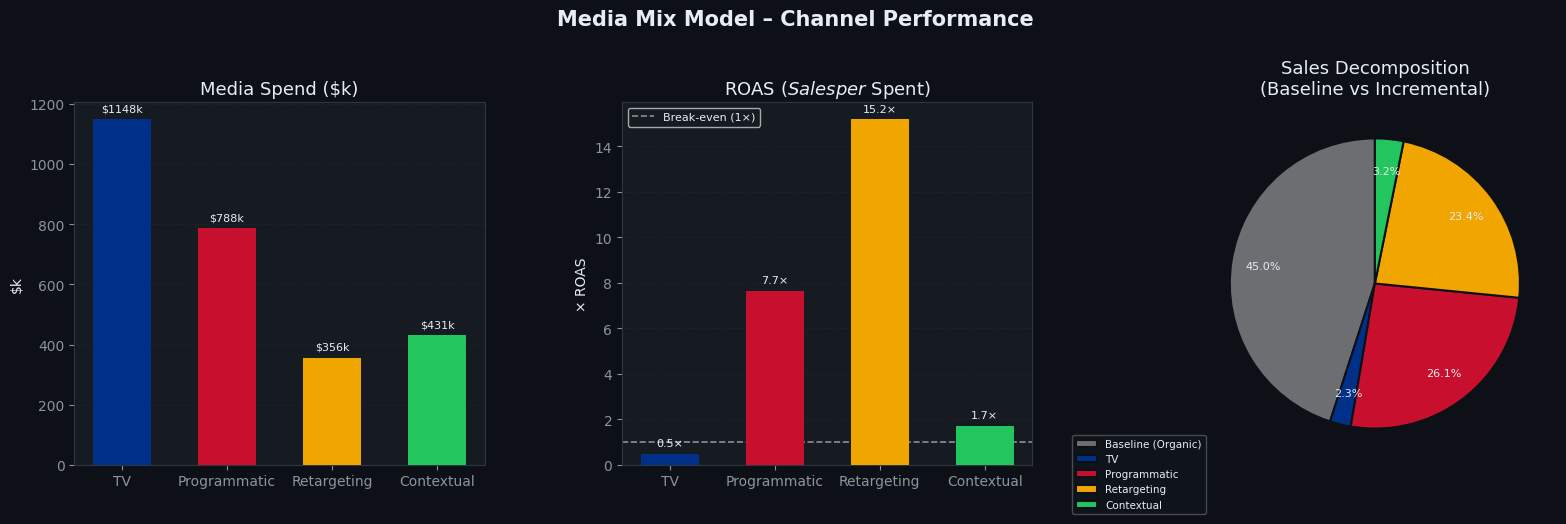

In [ ]:
# ----- Fig 1: ROAS & Spend by channel -----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Media Mix Model – Channel Performance", fontsize=15,
             color=TEXT_COLOR, fontweight="bold", y=1.02)

chs   = list(ch_df.index)
cols  = [ch_data[c]["color"] for c in chs]

# Spend
ax = axes[0]
bars = ax.bar(chs, ch_df["spend"] / 1e3, color=cols, width=0.55, zorder=3)
ax.set_title("Media Spend ($k)", color=TEXT_COLOR)
ax.set_ylabel("$k")
ax.bar_label(bars, fmt="$%.0fk", padding=4, color=TEXT_COLOR, fontsize=8)
ax.grid(axis="y", zorder=0)

# ROAS
ax = axes[1]
bars2 = ax.bar(chs, ch_df["ROAS"], color=cols, width=0.55, zorder=3)
ax.axhline(1.0, color="white", linestyle="--", lw=1.2, alpha=0.5, label="Break-even (1×)")
ax.set_title("ROAS ($ Sales per $ Spent)", color=TEXT_COLOR)
ax.set_ylabel("× ROAS")
ax.bar_label(bars2, fmt="%.1f×", padding=4, color=TEXT_COLOR, fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis="y", zorder=0)

# Sales decomposition
ax = axes[2]
sizes  = list(decomp.values())
labels = list(decomp.keys())
wedges, texts, auts = ax.pie(sizes, labels=None, autopct="%1.1f%%",
                              colors=decomp_colors, startangle=90,
                              wedgeprops=dict(edgecolor=DARK_BG, linewidth=1.5),
                              pctdistance=0.78, textprops={"color": TEXT_COLOR, "fontsize": 8})
ax.set_title("Sales Decomposition\n(Baseline vs Incremental)", color=TEXT_COLOR)
ax.legend(labels, loc="lower left", fontsize=7.5, framealpha=0.3,
          bbox_to_anchor=(-0.35, -0.15))
ax.set_facecolor(DARK_BG)

plt.tight_layout()


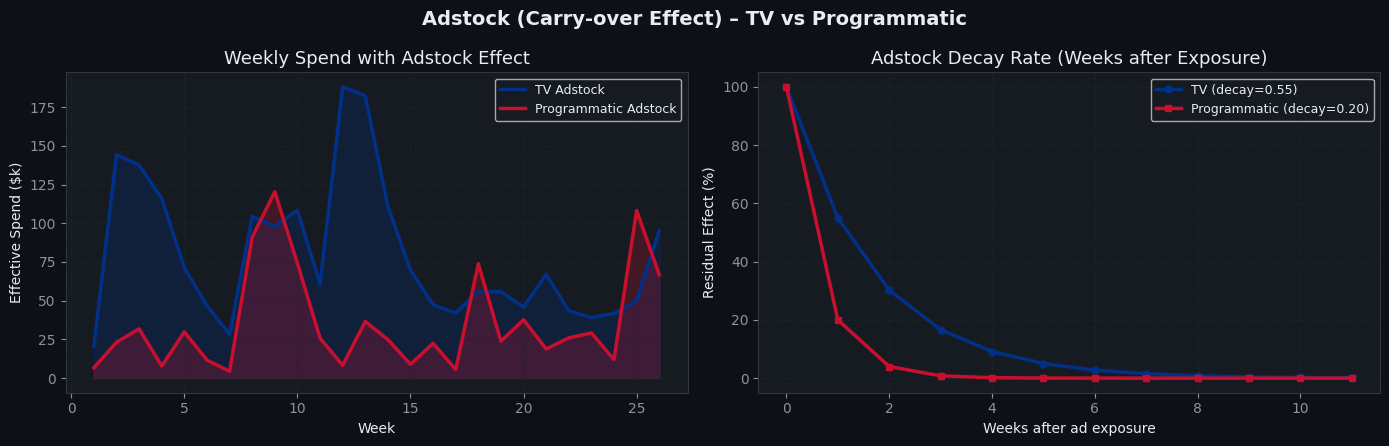

In [ ]:
# ----- Fig 2: Adstock / Carry-over over time -----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Adstock (Carry-over Effect) – TV vs Programmatic",
             fontsize=14, color=TEXT_COLOR, fontweight="bold")

weeks = np.arange(1, n_weeks + 1)
ax = axes[0]
ax.fill_between(weeks, tv_adstock / 1e3, alpha=0.25, color=TV_COLOR)
ax.plot(weeks, tv_adstock / 1e3, color=TV_COLOR, lw=2.5, label="TV Adstock")
ax.fill_between(weeks, prog_adstock / 1e3, alpha=0.25, color=PROG_COLOR)
ax.plot(weeks, prog_adstock / 1e3, color=PROG_COLOR, lw=2.5, label="Programmatic Adstock")
ax.set_title("Weekly Spend with Adstock Effect", color=TEXT_COLOR)
ax.set_xlabel("Week"); ax.set_ylabel("Effective Spend ($k)")
ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
decay_x = np.arange(0, 12)
tv_decay   = 0.55**decay_x
prog_decay = 0.20**decay_x
ax.plot(decay_x, tv_decay * 100,   color=TV_COLOR,   lw=2.5, marker="o", ms=5, label="TV (decay=0.55)")
ax.plot(decay_x, prog_decay * 100, color=PROG_COLOR, lw=2.5, marker="s", ms=5, label="Programmatic (decay=0.20)")
ax.set_title("Adstock Decay Rate (Weeks after Exposure)", color=TEXT_COLOR)
ax.set_xlabel("Weeks after ad exposure")
ax.set_ylabel("Residual Effect (%)")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()

# 6. PLOTS – Step4

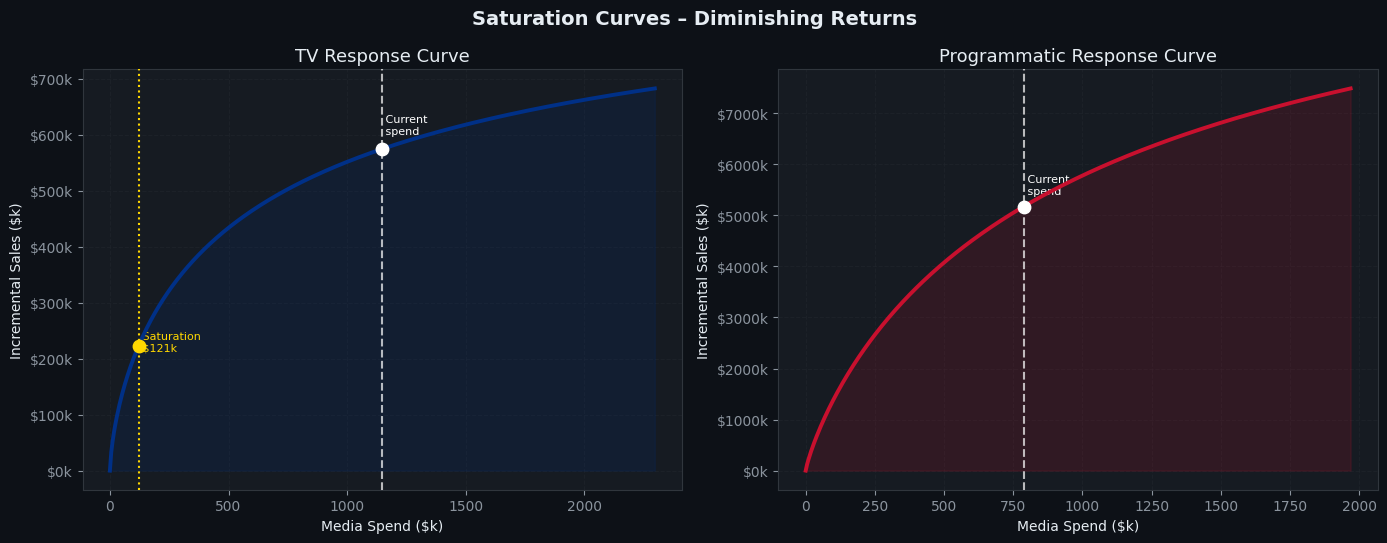

In [ ]:
# ----- Fig 3: Response Curves (Saturation) -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Saturation Curves – Diminishing Returns",
             fontsize=14, color=TEXT_COLOR, fontweight="bold")

for ax, spend_arr, response_arr, ch_name, color, cur_spend, sat_spend in [
    (axes[0], tv_spend_range,   tv_response_sales,   "TV",           TV_COLOR,   ch_data["TV"]["spend"],           tv_sat_spend),
    (axes[1], prog_spend_range, prog_response_sales, "Programmatic", PROG_COLOR, ch_data["Programmatic"]["spend"], prog_sat_spend),
]:
    ax.plot(spend_arr / 1e3, response_arr / 1e3, color=color, lw=2.8, zorder=4)
    ax.fill_between(spend_arr / 1e3, response_arr / 1e3, alpha=0.15, color=color, zorder=3)

    # Current spend marker
    cur_r = hill_sales(cur_spend, alpha_tv if ch_name == "TV" else alpha_prog,
                       K_tv if ch_name == "TV" else K_prog,
                       ch_data[ch_name]["sales"] * (1.8 if ch_name == "TV" else 2.0))
    ax.axvline(cur_spend / 1e3, color="white",  lw=1.5, linestyle="--", alpha=0.7, zorder=5)
    ax.scatter([cur_spend / 1e3], [cur_r / 1e3], color="white", s=80, zorder=6)
    ax.text(cur_spend / 1e3, cur_r / 1e3 * 1.04, " Current\n spend",
            color="white", fontsize=8, va="bottom")

    # Saturation point marker
    if sat_spend:
        sat_r = hill_sales(sat_spend, alpha_tv if ch_name == "TV" else alpha_prog,
                           K_tv if ch_name == "TV" else K_prog,
                           ch_data[ch_name]["sales"] * (1.8 if ch_name == "TV" else 2.0))
        ax.axvline(sat_spend / 1e3, color="#FFD700", lw=1.5, linestyle=":", zorder=5)
        ax.scatter([sat_spend / 1e3], [sat_r / 1e3], color="#FFD700", s=80, zorder=6)
        ax.text(sat_spend / 1e3 * 1.01, sat_r / 1e3 * 0.96,
                f" Saturation\n ${sat_spend/1e3:.0f}k", color="#FFD700", fontsize=8)

    ax.set_title(f"{ch_name} Response Curve", color=TEXT_COLOR)
    ax.set_xlabel("Media Spend ($k)")
    ax.set_ylabel("Incremental Sales ($k)")
    ax.grid(True); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))

plt.tight_layout()

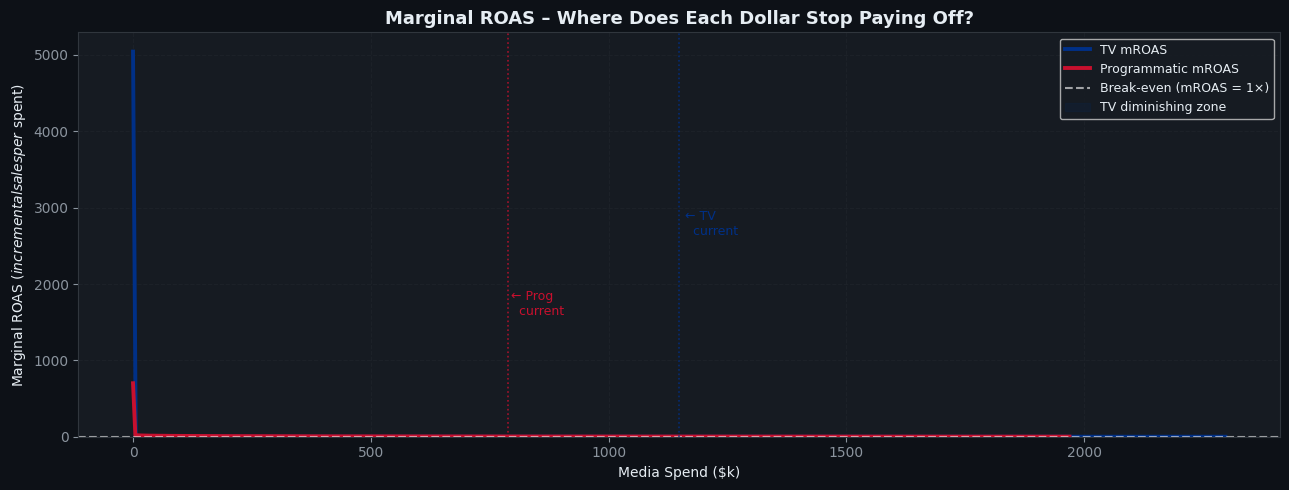

In [ ]:
# ----- Fig 4: Marginal ROAS curves -----
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title("Marginal ROAS – Where Does Each Dollar Stop Paying Off?",
             fontsize=13, color=TEXT_COLOR, fontweight="bold")

ax.plot(tv_spend_range / 1e3,   tv_mroas,   color=TV_COLOR,   lw=2.8, label="TV mROAS")
ax.plot(prog_spend_range / 1e3, prog_mroas, color=PROG_COLOR, lw=2.8, label="Programmatic mROAS")
ax.axhline(1.0, color="white", lw=1.5, linestyle="--", alpha=0.6, label="Break-even (mROAS = 1×)")

# Mark current spends
ax.axvline(ch_data["TV"]["spend"] / 1e3,           color=TV_COLOR,   lw=1.2, linestyle=":", alpha=0.8)
ax.axvline(ch_data["Programmatic"]["spend"] / 1e3, color=PROG_COLOR, lw=1.2, linestyle=":", alpha=0.8)

ax.text(ch_data["TV"]["spend"] / 1e3 * 1.01, ax.get_ylim()[1] * 0.5,
        "← TV\n  current", color=TV_COLOR, fontsize=9)
ax.text(ch_data["Programmatic"]["spend"] / 1e3 * 1.01, ax.get_ylim()[1] * 0.3,
        "← Prog\n  current", color=PROG_COLOR, fontsize=9)

# Shade "diminishing zone"
ax.fill_between(tv_spend_range / 1e3, tv_mroas,
                where=(tv_mroas < 2.0) & (tv_spend_range > ch_data["TV"]["spend"] * 0.4),
                alpha=0.10, color=TV_COLOR, label="TV diminishing zone")

ax.set_xlabel("Media Spend ($k)")
ax.set_ylabel("Marginal ROAS ($ incremental sales per $ spent)")
ax.legend(fontsize=9); ax.grid(True)
ax.set_ylim(bottom=0)

plt.tight_layout()

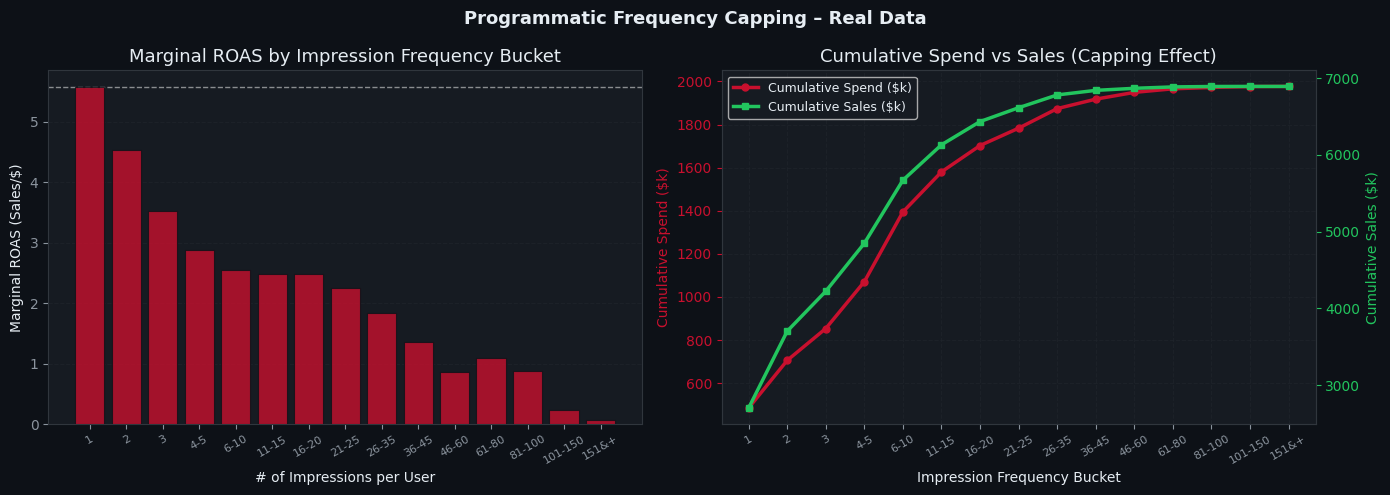

In [ ]:
# ----- Fig 5: Real capping data – frequency vs marginal return -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Programmatic Frequency Capping – Real Data",
             fontsize=13, color=TEXT_COLOR, fontweight="bold")

ax = axes[0]
ax.bar(bracket_x, cap["marginal_ROAS"], color=PROG_COLOR, alpha=0.8, zorder=3,
       edgecolor=DARK_BG, linewidth=0.8)
ax.axhline(cap["marginal_ROAS"].iloc[0], color="white", lw=1, linestyle="--", alpha=0.5)
ax.set_xticks(bracket_x); ax.set_xticklabels(bracket_labels, rotation=30, fontsize=8)
ax.set_title("Marginal ROAS by Impression Frequency Bucket", color=TEXT_COLOR)
ax.set_xlabel("# of Impressions per User")
ax.set_ylabel("Marginal ROAS (Sales/$)")
ax.grid(axis="y", zorder=0)

ax = axes[1]
ax2 = ax.twinx()
line1, = ax.plot(bracket_x, cum_spend / 1e3, color=PROG_COLOR, lw=2.5, marker="o", ms=5, label="Cumulative Spend ($k)")
line2, = ax2.plot(bracket_x, cum_sales / 1e3, color="#22C55E", lw=2.5, marker="s", ms=5, label="Cumulative Sales ($k)")
ax.set_xticks(bracket_x); ax.set_xticklabels(bracket_labels, rotation=30, fontsize=8)
ax.set_title("Cumulative Spend vs Sales (Capping Effect)", color=TEXT_COLOR)
ax.set_xlabel("Impression Frequency Bucket")
ax.set_ylabel("Cumulative Spend ($k)", color=PROG_COLOR)
ax2.set_ylabel("Cumulative Sales ($k)", color="#22C55E")
ax.tick_params(axis="y", colors=PROG_COLOR)
ax2.tick_params(axis="y", colors="#22C55E")
ax.legend(handles=[line1, line2], fontsize=9, loc="upper left")
ax.grid(True)

plt.tight_layout()

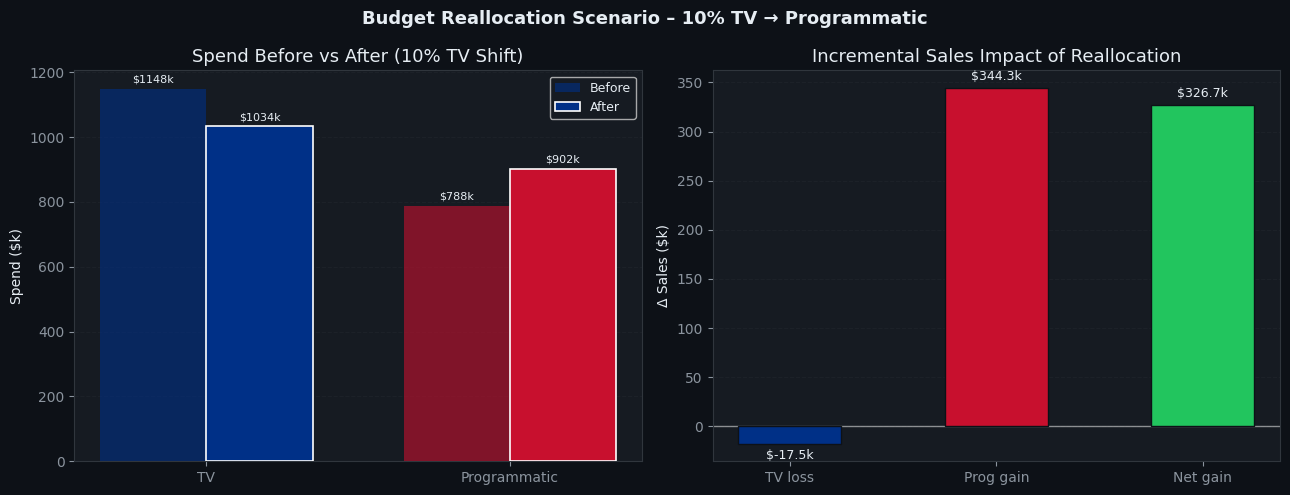

In [ ]:
# ----- Fig 6: Budget Reallocation Scenario -----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Budget Reallocation Scenario – 10% TV → Programmatic",
             fontsize=13, color=TEXT_COLOR, fontweight="bold")

# Before / After spend
labels = ["TV", "Programmatic"]
before = [ch_data["TV"]["spend"] / 1e3, ch_data["Programmatic"]["spend"] / 1e3]
after  = [new_tv_spend / 1e3,           new_prog_spend / 1e3]
x = np.arange(2)
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, before, w, label="Before", color=[TV_COLOR, PROG_COLOR], alpha=0.6, zorder=3)
b2 = ax.bar(x + w/2, after,  w, label="After",  color=[TV_COLOR, PROG_COLOR], alpha=1.0, zorder=3,
            edgecolor="white", linewidth=1.2)
ax.bar_label(b1, fmt="$%.0fk", padding=3, color=TEXT_COLOR, fontsize=8)
ax.bar_label(b2, fmt="$%.0fk", padding=3, color=TEXT_COLOR, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Spend Before vs After (10% TV Shift)", color=TEXT_COLOR)
ax.set_ylabel("Spend ($k)")
ax.legend(fontsize=9); ax.grid(axis="y", zorder=0)

ax = axes[1]
net_label  = f"+${net_gain/1e3:.1f}k\nnet gain"
scenario   = ["TV loss", "Prog gain", "Net gain"]
values     = [delta_tv / 1e3, delta_prog / 1e3, net_gain / 1e3]
bar_colors = [TV_COLOR, PROG_COLOR, "#22C55E" if net_gain > 0 else "#EF4444"]
bars = ax.bar(scenario, values, color=bar_colors, width=0.5, zorder=3, edgecolor=DARK_BG)
ax.axhline(0, color="white", lw=1, alpha=0.5)
ax.bar_label(bars, fmt="$%.1fk", padding=4, color=TEXT_COLOR, fontsize=9)
ax.set_title("Incremental Sales Impact of Reallocation", color=TEXT_COLOR)
ax.set_ylabel("Δ Sales ($k)")
ax.grid(axis="y", zorder=0)

plt.tight_layout()

In [ ]:
print("\n===== KEY NUMBERS =====")
for ch, d in ch_data.items():
    roas = d["sales"] / d["spend"]
    print(f"  {ch:15s}  Spend: ${d['spend']:>10,.0f}  Sales: ${d['sales']:>12,.0f}  ROAS: {roas:.2f}×")
print(f"\n  TV saturation ~${tv_sat_spend:,.0f}" if tv_sat_spend else "")
print(f"  Prog saturation ~${prog_sat_spend:,.0f}" if prog_sat_spend else "")
print(f"  Shift 10% TV → Prog:  net sales impact = ${net_gain/1e3:.1f}k")


===== KEY NUMBERS =====
  TV               Spend: $ 1,148,427  Sales: $     542,407  ROAS: 0.47×
  Programmatic     Spend: $   787,606  Sales: $   6,030,660  ROAS: 7.66×
  Retargeting      Spend: $   356,347  Sales: $   5,409,255  ROAS: 15.18×
  Contextual       Spend: $   431,259  Sales: $     734,938  ROAS: 1.70×

  TV saturation ~$120,887

  Shift 10% TV → Prog:  net sales impact = $326.7k
